In [17]:
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz

In [21]:
def compute_lp_residual(signal, p=10, frame_length_ms=25, fs=8000):
    # Frame parameters
    frame_length_samples = int(frame_length_ms * fs / 1000)  # Convert ms to samples
    num_frames = len(signal) // frame_length_samples  # Number of frames
    
    residual_signal = np.zeros_like(signal)  # Store residual signal
    
    # Process each frame
    for i in range(num_frames):
        start = i * frame_length_samples
        end = start + frame_length_samples
        frame = signal[start:end]
        
        # Apply Hamming window
        frame *= np.hamming(len(frame))
        
        # Compute autocorrelation
        autocorr = np.correlate(frame, frame, mode='full')
        autocorr = autocorr[len(frame)-1:len(frame)-1+p+1]  # Keep necessary part
        
        # Solve Yule-Walker equations to get LPC coefficients
        R = toeplitz(autocorr[:-1])  # Autocorrelation matrix
        r = autocorr[1:]  # Autocorrelation vector
        lpc_coeffs = np.linalg.solve(R, r)  # Solve linear system
        lpc_coeffs = np.concatenate(([1], -lpc_coeffs))  # Include a0 = 1
        
        # Compute LP residual (filtering the frame)
        residual = sig.lfilter(lpc_coeffs, [1], frame)
        residual_signal[start:end] = residual
    
    return residual_signal


In [22]:
def lp_synthesis(residual_signal, signal, p=10, frame_length_ms=25, fs=8000):
    # Frame parameters
    frame_length_samples = int(frame_length_ms * fs / 1000)  # Convert ms to samples
    num_frames = len(signal) // frame_length_samples  # Number of frames
    
    reconstructed_signal = np.zeros_like(signal)  # Store reconstructed signal
    
    # Process each frame
    for i in range(num_frames):
        start = i * frame_length_samples
        end = start + frame_length_samples
        frame = signal[start:end]
        
        # Apply Hamming window
        frame *= np.hamming(len(frame))
        
        # Compute autocorrelation
        autocorr = np.correlate(frame, frame, mode='full')
        autocorr = autocorr[len(frame)-1:len(frame)-1+p+1]  # Keep necessary part
        
        # Solve Yule-Walker equations to get LPC coefficients
        R = toeplitz(autocorr[:-1])  # Autocorrelation matrix
        r = autocorr[1:]  # Autocorrelation vector
        lpc_coeffs = np.linalg.solve(R, r)  # Solve linear system
        lpc_coeffs = np.concatenate(([1], -lpc_coeffs))  # Include a0 = 1
        
        # LP Synthesis: Reconstruct the speech by filtering the residual
        reconstructed_frame = sig.lfilter([1], lpc_coeffs, residual_signal[start:end])
        reconstructed_signal[start:end] = reconstructed_frame
    
    return reconstructed_signal

In [23]:
def lp_analysis_residual(file_path, p=10, frame_length_ms=25, fs=8000):
    # Load the speech file
    fs_read, signal = wav.read(file_path)
    assert fs_read == fs, f"Expected sampling rate {fs}, but got {fs_read}"  # Ensure correct sampling rate
    
    # Normalize signal
    signal = signal.astype(np.float32) / np.max(np.abs(signal))
    
    # Compute LP residual
    residual_signal = compute_lp_residual(signal, p, frame_length_ms, fs)
    
    # Compute LP synthesis (reconstruct speech)
    reconstructed_signal = lp_synthesis(residual_signal, signal, p, frame_length_ms, fs)
    
    time_axis = np.arange(len(signal)) / fs  # Time axis for original signal
    
    # Plot results
    plt.figure(figsize=(12, 6))
    
    # Plot original signal and residual
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, signal, label='Original Signal', color='b')
    plt.plot(time_axis, residual_signal, label='Residual Signal', color='r', alpha=0.7)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Original Speech Signal and LP Residual')
    plt.legend()
    
    # Plot reconstructed signal
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, reconstructed_signal, label='Reconstructed Signal', color='g')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Reconstructed Speech Signal from Residual')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

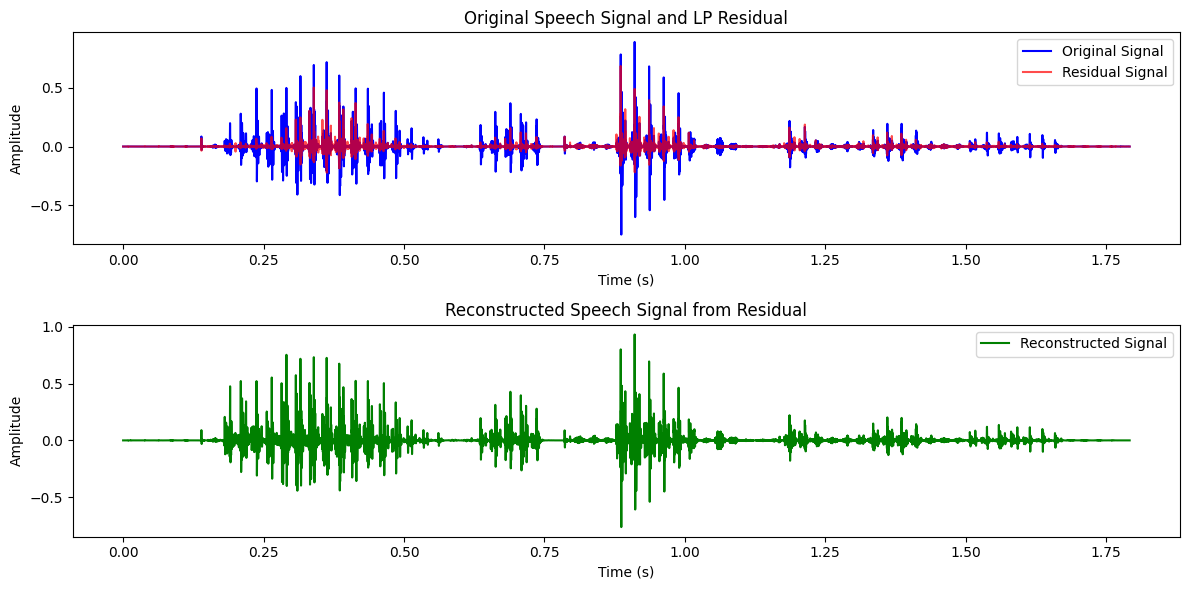

In [24]:
lp_analysis_residual('Male_sentences_8kHz/si745_8kHz.wav')

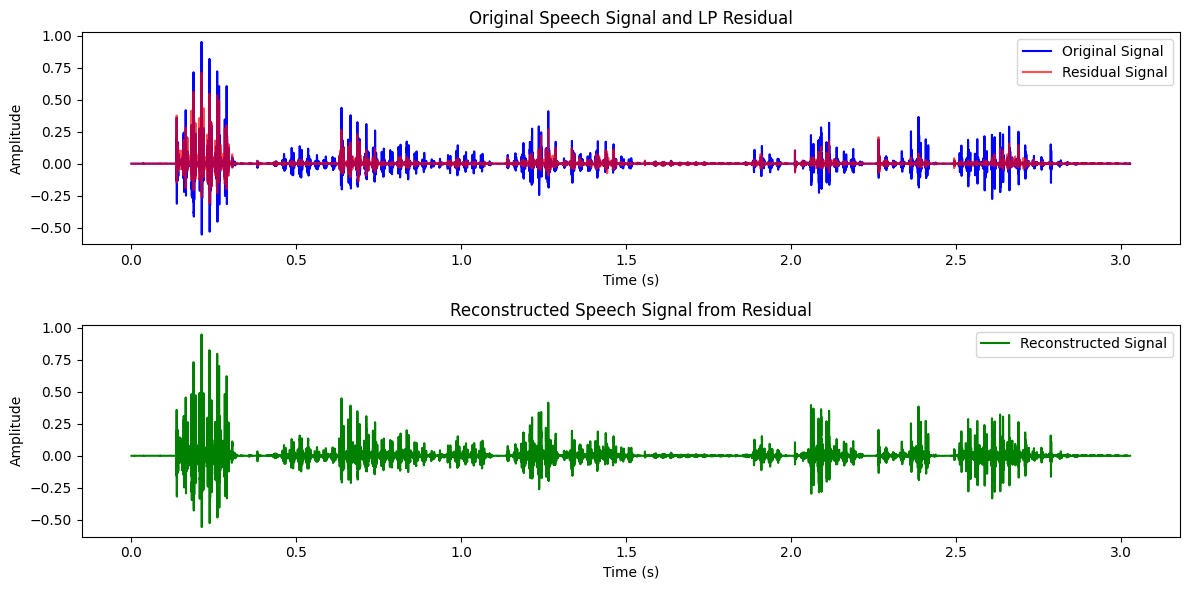

In [25]:
lp_analysis_residual('Female_sentences_8kHz/si747_8kHz.wav')